# Thin-sheet IE forward modeling (WSHEET20, **Fortran**) — 3 scenarios

Same three scenarios as the Python notebook (`IE_forward_github.ipynb`), but computed with the **original Fortran code** compiled and executed from this notebook, so the two implementations can be compared file-for-file and plot-for-plot.

Model: vertical thin sheet at x = 500 m (200 x 200 m, 0.1 m thick) in a 10 ohm-m whole space, vertical magnetic dipole (VMD) at the origin, 201 receivers along x = 0-1000 m at z = 0.75 m, f = 100 Hz.

At 100 Hz the skin depth in the 10 ohm-m host is ~159 m (vs ~11 m at 20 kHz), so the fields survive along the whole 1 km line and the sheet anomaly is much more prominent.

| Scenario | Sheet | Program | it_s | Output file |
|---|---|---|---|---|
| 1 conductive | rho = 1e-5 ohm-m (tau ~ 1e4 S) | `wsheet20` | 0 (compute + store `decomp.lud`) | `h-field-FORTRAN-conductive-100Hz.dat` |
| 2 zero-contrast | rho = 10.000001 ohm-m (tau ~ -1e-9 S) | `wsheet20` | 1 (compute, don't store) | `h-field-FORTRAN-zerocontrast-100Hz.dat` |
| 3 background | sheet removed | `background20` (companion, below) | — | `h-field-FORTRAN-background-100Hz.dat` |

**Scenario 3 note:** `wsheet20.f` cannot represent "no sheet" (the system matrix contains 1/tau, singular at zero contrast), so this notebook writes and compiles a small companion program `background20.f` that reads the *same* `wsheet20.par`, evaluates only the whole-space primary field of the source at the receivers (formulas identical to subroutine `PRIMARY` of `WSHEET20.F`), and writes zero secondaries in exactly the same `h-field.dat` format.

**Requirements:** `gfortran` on the PATH (Linux/macOS: package manager; Windows: MinGW-w64 or MSYS2), plus numpy/pandas/matplotlib.

**Runtime:** scenarios 1 and 2 each take roughly **10-20 minutes** (the Fortran evaluates ~650k Romberg integrals for the 201 receivers); scenario 3 takes seconds. Progress is streamed below the run cells.

In [1]:
import os, sys, shutil, subprocess, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXE = '.exe' if os.name == 'nt' else ''

def fetch(fname, url):
    """Download a source file from the GitHub repo unless it is already here."""
    if os.path.exists(fname):
        print(f'{fname}: already present ({os.path.getsize(fname)} bytes)')
        return
    urllib.request.urlretrieve(url, fname)
    print(f'{fname}: downloaded ({os.path.getsize(fname)} bytes)')

def compile_fortran(exe_name, *sources):
    """Compile with gfortran.  -std=legacy is needed for the F77 PAUSE
    statement etc.; -fno-automatic gives Fortran locals static storage,
    which the Numerical-Recipes TRAPZD in SUB_LUD.f relies on (its stage
    counter IT must persist between calls)."""
    cmd = ['gfortran', '-O2', '-std=legacy', '-fno-automatic',
           '-o', exe_name + EXE, *sources]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f'compilation of {exe_name} failed - is gfortran installed?')
    print('compiled:', exe_name + EXE)

def run_exe(exe_name, echo_every=20):
    """Run a compiled executable in the current folder, streaming progress.
    (The executables read the fixed file name wsheet20.par.)"""
    exe = os.path.abspath(exe_name + EXE)
    proc = subprocess.Popen([exe], stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True)
    n_rx_lines = 0
    for line in proc.stdout:
        line = line.rstrip()
        if 'for Rx' in line:
            n_rx_lines += 1
            if n_rx_lines % echo_every == 1:
                print(line)
        elif line:
            print(line)
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f'{exe_name} exited with code {proc.returncode}')
    print(f'>>> {exe_name} finished ({n_rx_lines} receiver lines)')

## Get the original Fortran sources and compile

In [2]:
RAW = 'https://raw.githubusercontent.com/ivanprovozin/vert_thin_sheet_1km_line/main/'
fetch('wsheet20.f', RAW + 'wsheet20.f')
fetch('SUB_LUD.f',  RAW + 'SUB_LUD.f')

wsheet20.f: downloaded (59041 bytes)
SUB_LUD.f: downloaded (27164 bytes)


In [3]:
%%writefile background20.f
      program background20
c-------------------------------------------------------------------------------
c---- Program BACKGROUND20.F  (companion to WSHEET20.F)
c---- Whole-space (background-only) EM response: the sheet is completely
c---- removed from the model.  Only the primary field of the source is
c---- computed at the receivers; the secondary field is written as exact
c---- zeros.  Host properties, frequency, source and receiver layout are
c---- read from the same parameter file 'wsheet20.par' (its sheet-related
c---- entries are read but IGNORED).  Output files have exactly the same
c---- layout as those of WSHEET20 ('e-field.dat' / 'h-field.dat').
c---- The primary-field formulas are identical to subroutine PRIMARY of
c---- WSHEET20.F.
c-------------------------------------------------------------------------------
      dimension res_l(2), res_h(2), res_tau(2), res_alp(2)
      dimension eps_l(2), eps_h(2), eps_tau(2), eps_alp(2), thick(2)
      dimension na(2), nb(2)
      dimension x_top(2), y_top(2), z_top(2)
      dimension aa(2), bb(2), alpd(2), betd(2)
      complex admit, imped, i_no, c_null, cole, i_om, wave_s
      complex sig_n, eps_n, res_n
      complex f_prim(2,3), f_sec(2,3)
      integer nprt(4)
      common /parm/ omega, pi
      common /prop/ admit, imped, wave_s
      common /txrx/ ns_type, ns_dir, angle
      common /const/ i_no, c_null, conv
c
      pi = 4.*atan(1.)
      eps0 = 8.85419e-12
      amyu0 = 4.e-7*pi
      conv = pi/180.
      i_no = cmplx (0.0, 1.0)
      c_null = cmplx (0.0, 0.0)
c
c---- read the parameter file (same order as WSHEET20; sheet data ignored)
c
      open (2,file='wsheet20.par',status='old')
      read (2,*)
      read (2,*) no_sheet
      read (2,*)
      do i = 1, no_sheet
         read (2,*) na(i), nb(i)
      enddo
      read (2,*)
      do i = 1, no_sheet
         read (2,*) x_top(i), y_top(i), z_top(i)
      enddo
      read (2,*)
      do i = 1, no_sheet
         read (2,*) aa(i), bb(i), alpd(i), betd(i), thick(i)
      enddo
      read (2,*)
      do i = 1, no_sheet
         read (2,*) res_l(i), res_h(i), res_tau(i), res_alp(i)
      enddo
      read (2,*)
      do i = 1, no_sheet
         read (2,*) eps_l(i), eps_h(i), eps_tau(i), eps_alp(i)
      enddo
      read (2,*)
      read (2,*) resn_l, resn_h, resn_tau, resn_alp
      read (2,*)
      read (2,*) epsn_l, epsn_h, epsn_tau, epsn_alp
      read (2,*)
      read (2,*) freq
      read (2,*)
      read (2,*) ns_type, ns_dir, angle
      read (2,*)
      read (2,*) n_tx
      read (2,*)
      read (2,*) xs_s, ys_s, zs_s
      read (2,*) xs_i, ys_i, zs_i
      read (2,*)
      read (2,*) n_rx
      read (2,*)
      read (2,*) xr_s, yr_s, zr_s
      read (2,*) xr_i, yr_i, zr_i
      read (2,*)
      read (2,*) it_s
      read (2,*)
      read (2,*) (nprt(ip),ip=1,4)
      close (2)
c
      angle = angle * conv
      omega = 2.*pi*freq
      i_om = i_no*omega
c
c---- whole-space (host) properties only -- there is NO sheet
c
      res_n = cole(resn_l,resn_h,resn_tau,resn_alp)
      eps_n = cole(epsn_l,epsn_h,epsn_tau,epsn_alp) * eps0
      sig_n = 0.0
      if (cabs(res_n) .gt. 0.) sig_n = 1./res_n
      admit = sig_n + i_om*eps_n
      imped = i_om*amyu0
      wave_s = -admit*imped
c
      do ic = 1, 2
         do id = 1, 3
            f_sec(ic,id) = c_null
         enddo
      enddo
c
      if (nprt(2) .eq. 0) then
         open (8,file='e-field.dat')
         write(8,10)
      endif
      if (nprt(3) .eq. 0) then
         open (9,file='h-field.dat')
         write(9,10)
      endif
c
      do it = 1, n_tx
         xs = xs_s + (it-1.)*xs_i
         ys = ys_s + (it-1.)*ys_i
         zs = zs_s + (it-1.)*zs_i
         if (n_tx .eq. 1) then
            do ir = 1, n_rx
               write(*,*)
     2         '>>> Primary (background-only) computation for Rx', ir
               xr = xr_s + (ir-1.)*xr_i
               yr = yr_s + (ir-1.)*yr_i
               zr = zr_s + (ir-1.)*zr_i
               call primary(xs,ys,zs,xr,yr,zr,f_prim)
               call out_data (n_tx,nprt,xs,ys,zs,xr,yr,zr,f_prim,f_sec)
            enddo
         else
            write(*,*)
     2      '>>> Primary (background-only) computation for Tx', it
            xr = xr_s + (it-1.)*xr_i
            yr = yr_s + (it-1.)*yr_i
            zr = zr_s + (it-1.)*zr_i
            call primary(xs,ys,zs,xr,yr,zr,f_prim)
            call out_data (n_tx,nprt,xs,ys,zs,xr,yr,zr,f_prim,f_sec)
         endif
      enddo
c
      if (nprt(2) .eq. 0) close(8)
      if (nprt(3) .eq. 0) close(9)
10    format (3x,'X',7x,'Y',7x,'Z', 7x,'Secondary - X',
     2 10x,'Total - X',12x,'Secondary - Y',10x,'Total - Y',
     3 12x,'Secondary - Z',10x,'Total - Z'/)
      stop
      end
c
c-------------------------------------------------------------------------------
c---- identical to subroutine OUT_DATA of WSHEET20.F
c-------------------------------------------------------------------------------
c
      subroutine out_data (n_tx,nprt,xs,ys,zs,xr,yr,zr,f_prim,f_sec)
      complex f_prim(2,3), f_sec(2,3), total(3), rel(3), c_norm
      integer nprt(4)
      common /txrx/ ns_type, ns_dir, angle
c
      if (n_tx .eq. 1) then
            xm = xr
            ym = yr
            zm = zr
         else
            xm = 0.5 * (xs + xr)
            ym = 0.5 * (ys + yr)
            zm = 0.5 * (zs + zr)
      endif
c
      do ip = 2,3
         ip1 = ip - 1
         ifr = ip + 6
         if (nprt(ip) .eq. 0) then
            do i = 1,3
               rel(i) = f_sec(ip1,i)
               total(i) = f_prim(ip1,i) + rel(i)
            enddo
            if (nprt(4) .ne. 0) then
               do i = 1,3
                  c_norm = f_prim(ip1,i)
                  if (nprt(4) .eq. 2) c_norm = f_prim(ip1,ns_dir)
                  rel(i) = rel(i) / c_norm
                  total(i) = total(i) / c_norm
               enddo
            endif
            write(ifr,20) xm,ym,zm,(rel(i),total(i),i=1,3)
         endif
      enddo
c
20    format (3f8.1,12(1x,1p1e11.4))
      return
      end
c
c-------------------------------------------------------------------------------
c---- identical to subroutine PRIMARY of WSHEET20.F
c-------------------------------------------------------------------------------
c
      subroutine primary (xs,ys,zs,xr,yr,zr,f_prim)
      complex admit, imped, wavep, i_no, ikr, e_ikr, c_null
      complex Ex, Ey, Ez, c_ratio, deriv_0, deriv_1, deriv_2
      complex Hx, Hy, Hz, f_prim(2,3), wave_s
      common /prop/ admit, imped, wave_s
      common /const/ i_no, c_null, conv
      common /parm/ omega, pi
      common /txrx/ ns_type, ns_dir, angle
c
      pi4 = 0.25 / pi
      wavep = csqrt(wave_s)
c
      x_dist = xr - xs
      y_dist = yr - ys
      z_dist = zr - zs
      rr = sqrt(x_dist**2. + y_dist**2. + z_dist**2.)
      ikr = i_no*wavep*rr
      e_ikr = cexp(-ikr)
      dx = x_dist / rr
      dy = y_dist / rr
      dz = z_dist / rr
      deriv_0 = e_ikr / rr
      deriv_1 = e_ikr * (ikr + 1.) / rr**2.
      deriv_2 = e_ikr * (ikr*ikr + 3.*ikr + 3) / rr**3.
c
c---- electric dipole source
c
      if (ns_type .eq. 1) then
           c_ratio = imped / admit
           if (ns_dir .eq. 1) then
                Ex = - admit*deriv_0
     2               + (-deriv_1/rr + deriv_2*dx**2.) / imped
                Ey = deriv_2*dx*dy / imped
                Ez = deriv_2*dz*dx / imped
                Hx = c_null
                Hy = -deriv_1*dz
                Hz = deriv_1*dy
              elseif (ns_dir .eq. 2) then
                Ex = deriv_2*dx*dy / imped
                Ey = -admit*deriv_0
     2               + (-deriv_1/rr + deriv_2*dy**2.) / imped
                Ez = deriv_2*dy*dz / imped
                Hx = deriv_1*dz
                Hy = c_null
                Hz = -deriv_1*dx
              else
                Ex = deriv_2*dz*dx / imped
                Ey = deriv_2*dx*dy / imped
                Ez = -admit*deriv_0
     2               + (-deriv_1/rr + deriv_2*dz**2.) / imped
                Hx = -deriv_1*dy
                Hy = deriv_1*dx
                Hz = c_null
           endif
           f_prim(1,1) = Ex * c_ratio * pi4
           f_prim(1,2) = Ey * c_ratio * pi4
           f_prim(1,3) = Ez * c_ratio * pi4
           f_prim(2,1) = Hx * pi4
           f_prim(2,2) = Hy * pi4
           f_prim(2,3) = Hz * pi4
c
c---- magnetic dipole source (plane wave also falls through here,
c---- exactly as in WSHEET20's PRIMARY)
c
         else
           if (ns_dir .eq. 1) then
                Ex = c_null
                Ey = deriv_1*dz
                Ez = -deriv_1*dy
                Hx = wave_s*deriv_0 -deriv_1/rr + deriv_2*dx**2.
                Hy = deriv_2*dx*dy
                Hz = deriv_2*dz*dx
              elseif (ns_dir .eq. 2) then
                Ex = -deriv_1*dz
                Ey = c_null
                Ez = deriv_1*dx
                Hx = deriv_2*dx*dy
                Hy = wave_s*deriv_0 -deriv_1/rr + deriv_2*dy**2.
                Hz = deriv_2*dy*dz
              else
                Ex = deriv_1*dy
                Ey = -deriv_1*dx
                Ez = c_null
                Hx = deriv_2*dz*dx
                Hy = deriv_2*dy*dz
                Hz = wave_s*deriv_0 -deriv_1/rr + deriv_2*dz**2.
           endif
           f_prim(1,1) = pi4 * imped * Ex
           f_prim(1,2) = pi4 * imped * Ey
           f_prim(1,3) = pi4 * imped * Ez
           f_prim(2,1) = pi4 * Hx
           f_prim(2,2) = pi4 * Hy
           f_prim(2,3) = pi4 * Hz
      endif
c
      return
      end
c
c-------------------------------------------------------------------------------
c---- identical to complex function COLE of WSHEET20.F
c-------------------------------------------------------------------------------
c
      complex function cole(z_l,z_h,tau,alpha)
      complex i_om
      common /parm/ omega, pi
c
      i_om = cmplx(0.0, 1.0) * omega
      if ((z_l.lt.z_h) .or. (alpha.gt.1.0)) then
            write(*,*) '>> INVALID COLE-COLE PARAMETERS !!'
            stop
      endif
      if (tau .lt. 1.e-12) then
            cole = cmplx(1.0, 0.0) * z_l
          else
            cole = z_h + (z_l - z_h) / (1.+(i_om*tau)**alpha)
      endif
c
      return
      end


Writing background20.f


In [4]:
compile_fortran('wsheet20', 'wsheet20.f', 'SUB_LUD.f')
compile_fortran('background20', 'background20.f')

compiled: wsheet20
compiled: background20


## Scenario 1 — conductive sheet
Identical to the repo's `wsheet20.par` except `it_s = 0` so the LU decomposition is computed here and stored in `decomp.lud` (the repo par uses `it_s = 2`, which requires a pre-existing `decomp.lud` and stops otherwise). Runtime ~10-20 min.

In [5]:
%%writefile wsheet20_s1.par
>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet
1.d-5  1.d-6  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet
2.   2.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
100.
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Perform Green's function integral and SVD (0,1) or use previous SVD data(2)
0
>> output control parameter scattering, e_field, h_field, normalizing
1  1  0  0


Writing wsheet20_s1.par


In [6]:
shutil.copyfile('wsheet20_s1.par', 'wsheet20.par')   # the exe reads this fixed name
run_exe('wsheet20')
shutil.copyfile('h-field.dat', 'h-field-FORTRAN-conductive-100Hz.dat')
print('wrote h-field-FORTRAN-conductive-100Hz.dat')

 >>> GREEN FUNCTION $ POTENTIAL EVALUATION
      For Sheet No. S           1
 >>> LU DECOMPOSITION
 >>> Primary and Secondary Field computation for Rx           1
 >>> Primary and Secondary Field computation for Rx          21
 >>> Primary and Secondary Field computation for Rx          41
 >>> Primary and Secondary Field computation for Rx          61
 >>> Primary and Secondary Field computation for Rx          81
 >>> Primary and Secondary Field computation for Rx         101
 >>> Primary and Secondary Field computation for Rx         121
 >>> Primary and Secondary Field computation for Rx         141
 >>> Primary and Secondary Field computation for Rx         161
 >>> Primary and Secondary Field computation for Rx         181
 >>> Primary and Secondary Field computation for Rx         201
>>> wsheet20 finished (201 receiver lines)
wrote h-field-FORTRAN-conductive-100Hz.dat


## Scenario 2 — zero-contrast sheet
Sheet resistivity 10.000001 ohm-m against the 10 ohm-m host (tau ~ -1e-9 S; exact zero contrast is not representable because the formulation contains 1/tau). `it_s = 1`: the system matrix depends on tau, so the scenario-1 `decomp.lud` cannot be reused. Runtime ~10-20 min.

In [7]:
%%writefile wsheet20_s2.par
>> No. of sheet
1
>> No. of cells for strike and dip direction (max = 20)
20  20
>> xyz coordinate of the center of the sheets before rotation 
500.  0. -200.
>> strike length (m), dip length(m), strike (deg), dip (deg),thickness(m) of each sheet
200. 200.  90. 90. 0.1
>> Cole-Cole parameter of resistivity of each sheet
10.000001  10.000001  0.  0.5
>> Cole-Cole parameter of relative permittivity of each sheet  (= host)
10.   10.  0.  0.5
>> Cole-Cole parameter of resistivity of whole space
10. 10.  0.  0.5
>> Cole-Cole parameter of dielectric constant of whole space
10.  10.  0.  0.5
>> Frequency (Hz)
100.
>> source type (0=plane, 1=J type, 2=M type), direction (1=x,2=y,3=z), angle
2   3   0.
>> No. of Tx
1
>> start x,y,z coordinates of the sources and increments
0., 0., 0.0
0.,  0.,  0.0
>> No. of Rx
201
>> start x,y,z coordinates of the Receivers and increments
0., 0.,  0.75
5.,  0.,  0.0
>> Perform Green's function integral and SVD (0,1) or use previous SVD data(2)
1
>> output control parameter scattering, e_field, h_field, normalizing
1  1  0  0


Writing wsheet20_s2.par


In [8]:
shutil.copyfile('wsheet20_s2.par', 'wsheet20.par')
run_exe('wsheet20')
shutil.copyfile('h-field.dat', 'h-field-FORTRAN-zerocontrast-100Hz.dat')
print('wrote h-field-FORTRAN-zerocontrast-100Hz.dat')

 >>> GREEN FUNCTION $ POTENTIAL EVALUATION
      For Sheet No. S           1
 >>> LU DECOMPOSITION
 >>> Primary and Secondary Field computation for Rx           1
 >>> Primary and Secondary Field computation for Rx          21
 >>> Primary and Secondary Field computation for Rx          41
 >>> Primary and Secondary Field computation for Rx          61
 >>> Primary and Secondary Field computation for Rx          81
 >>> Primary and Secondary Field computation for Rx         101
 >>> Primary and Secondary Field computation for Rx         121
 >>> Primary and Secondary Field computation for Rx         141
 >>> Primary and Secondary Field computation for Rx         161
 >>> Primary and Secondary Field computation for Rx         181
 >>> Primary and Secondary Field computation for Rx         201
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
>>> wsheet20 finished (201 receiver lines)
wrote h-field-FORTRAN-zerocontrast-100Hz.dat


## Scenario 3 — background only (sheet removed)
The companion `background20` program with the scenario-1 parameter file (its sheet entries are read but ignored). Secondary fields are written as exact zeros; the total field is the whole-space primary of the VMD source. Runs in seconds.

In [9]:
shutil.copyfile('wsheet20_s1.par', 'wsheet20.par')
run_exe('background20', echo_every=100)
shutil.copyfile('h-field.dat', 'h-field-FORTRAN-background-100Hz.dat')
print('wrote h-field-FORTRAN-background-100Hz.dat')

 >>> Primary (background-only) computation for Rx           1
 >>> Primary (background-only) computation for Rx         101
 >>> Primary (background-only) computation for Rx         201
>>> background20 finished (201 receiver lines)
wrote h-field-FORTRAN-background-100Hz.dat


## Quick checks on the three Fortran output files

In [10]:
COLS = ['X', 'Y', 'Z',
        'Sec_X_Re', 'Sec_X_Im', 'Tot_X_Re', 'Tot_X_Im',
        'Sec_Y_Re', 'Sec_Y_Im', 'Tot_Y_Re', 'Tot_Y_Im',
        'Sec_Z_Re', 'Sec_Z_Im', 'Tot_Z_Re', 'Tot_Z_Im']
SEC = [c for c in COLS if c.startswith('Sec')]
TOT = [c for c in COLS if c.startswith('Tot')]

fort = {s: pd.read_csv(f'h-field-FORTRAN-{s}-100Hz.dat', sep=r'\s+',
                       skiprows=1, names=COLS)
        for s in ('conductive', 'zerocontrast', 'background')}

for s in fort:
    print(f"{s:13s}: max |secondary| = "
          f"{np.abs(fort[s][SEC].to_numpy()).max():.4e} A/m")

assert (fort['background'][SEC].to_numpy() == 0).all(), 'scenario 3 secondaries not zero!'
d = np.abs(fort['zerocontrast'][TOT].to_numpy()
           - fort['background'][TOT].to_numpy()).max()
print(f"\nmax |Total(zero-contrast) - Total(background)| = {d:.3e} A/m")

# background totals vs an independent evaluation of the analytic whole-space VMD Hz
om = 2*np.pi*100.0
k2 = -1j*om*(4.0e-7*np.pi)*(1.0/10.0 + 1j*om*10.0*8.85419e-12)
kk = np.sqrt(k2)
if kk.imag > 0:
    kk = -kk
xr = fort['background']['X'].to_numpy()
rr = np.sqrt(xr**2 + 0.75**2)
ikr = 1j*kk*rr
Hz_a = (1/(4*np.pi))*np.exp(-ikr)/rr**5*((3*0.75**2 - rr**2)*(1 + ikr)
                                         + (0.75**2 - rr**2)*ikr**2)
Hz_f = (fort['background']['Tot_Z_Re'].to_numpy()
        + 1j*fort['background']['Tot_Z_Im'].to_numpy())
nz = np.abs(Hz_a) > 1e-30
rel = np.abs(Hz_f[nz] - Hz_a[nz]) / np.abs(Hz_a[nz])
print(f"background Hz vs independent analytic: max rel diff = {rel.max():.3e} "
      f"(file stores 5 significant digits; Fortran is single precision)")
print("\nAll three FORTRAN output files written and checked.")

conductive   : max |secondary| = 2.0193e-09 A/m
zerocontrast : max |secondary| = 2.7020e-20 A/m
background   : max |secondary| = 0.0000e+00 A/m

max |Total(zero-contrast) - Total(background)| = 1.336e-23 A/m
background Hz vs independent analytic: max rel diff = 4.059e-05 (file stores 5 significant digits; Fortran is single precision)

All three FORTRAN output files written and checked.


## Plots: total field (symlog) and secondary field (linear) for each run
Same axes and style as the Python notebook, for one-to-one visual comparison.

In [11]:
plt.rcParams.update({'font.size': 12})


def plot_total(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['X'], df['Tot_X_Re'], lw=2, color='green',  label='X')
    ax.plot(df['X'], df['Tot_Y_Re'], lw=2, color='blue',   label='Y')
    ax.plot(df['X'], df['Tot_Z_Re'], lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.set_yscale('symlog', linthresh=1e-12)   # 100 Hz: fields reach ~1e-11 at x=1 km
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Total field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_secondary(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['X'], df['Sec_X_Re'], lw=2, color='green',  label='X')
    ax.plot(df['X'], df['Sec_Y_Re'], lw=2, color='blue',   label='Y')
    ax.plot(df['X'], df['Sec_Z_Re'], lw=2, color='orange', label='Z')
    ax.set_xlim(0, 1000)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('Magnetic Field (A/m)')
    ax.set_title(f'Secondary field (X,Y,Z) vs receiver line — {title}')
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

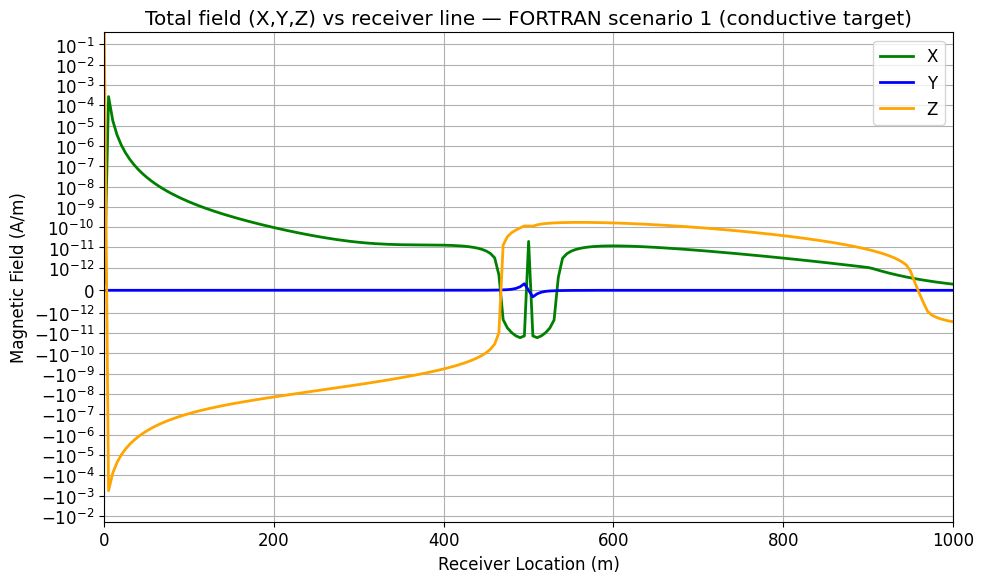

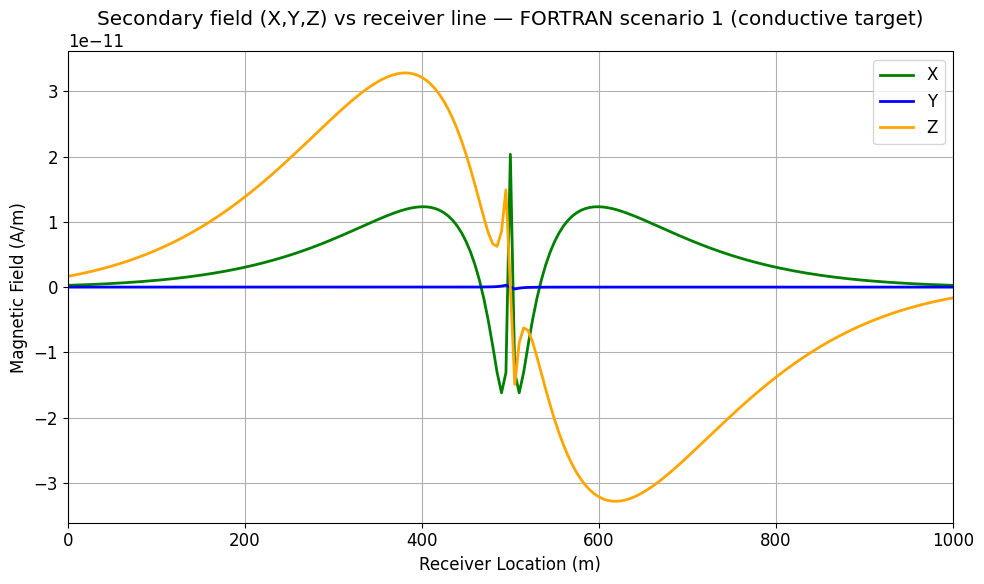

In [12]:
plot_total(fort['conductive'], 'FORTRAN scenario 1 (conductive target)')
plot_secondary(fort['conductive'], 'FORTRAN scenario 1 (conductive target)')

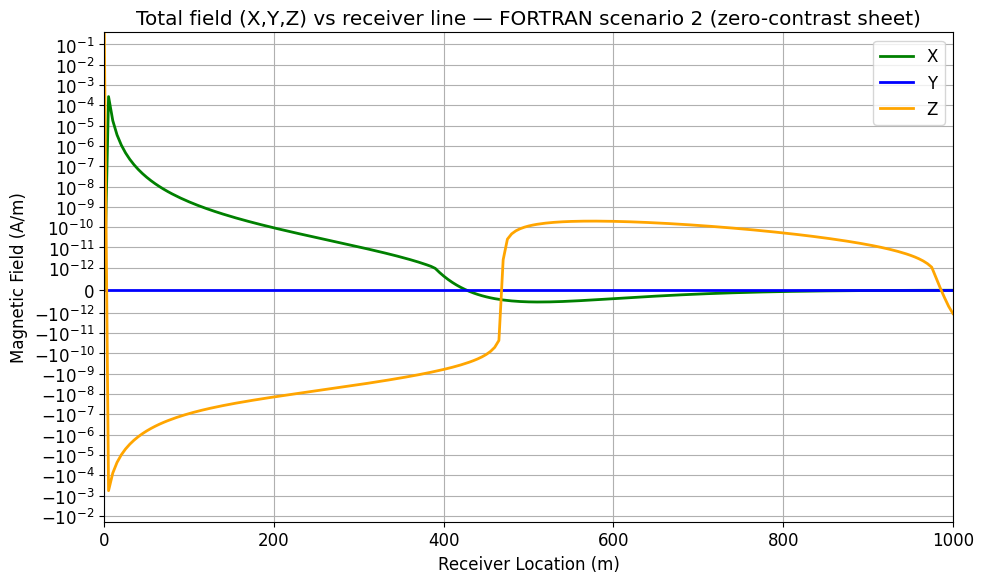

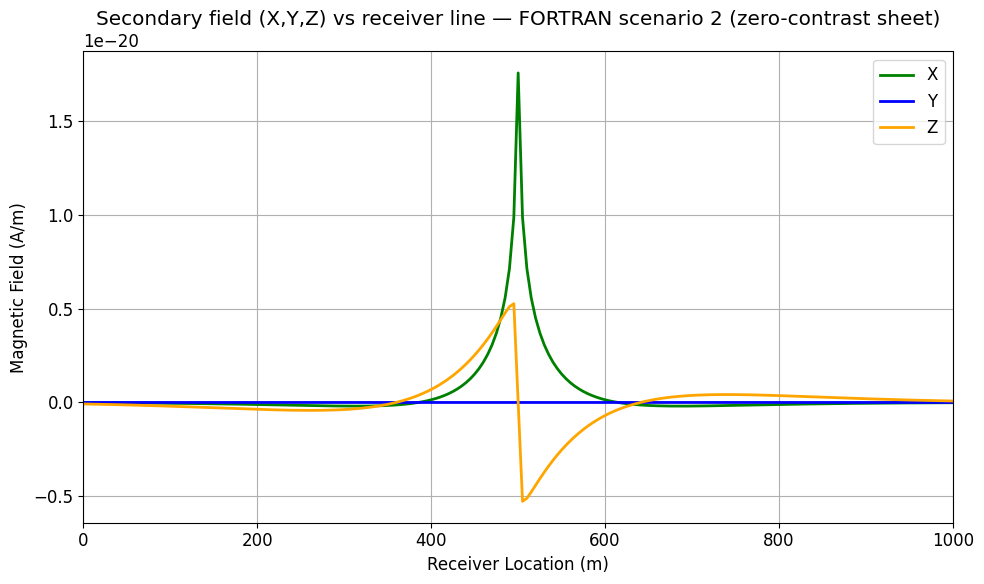

In [13]:
plot_total(fort['zerocontrast'], 'FORTRAN scenario 2 (zero-contrast sheet)')
plot_secondary(fort['zerocontrast'], 'FORTRAN scenario 2 (zero-contrast sheet)')

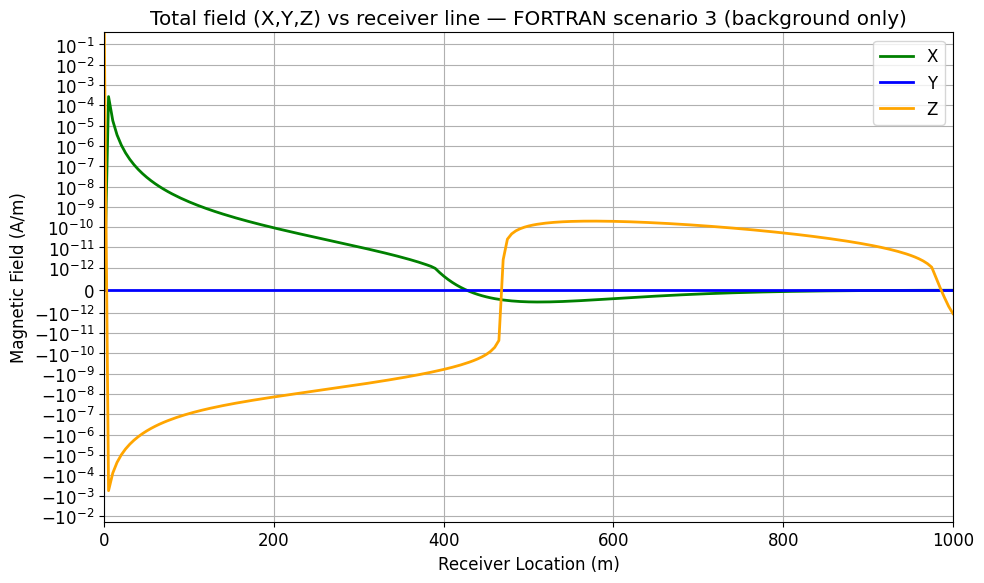

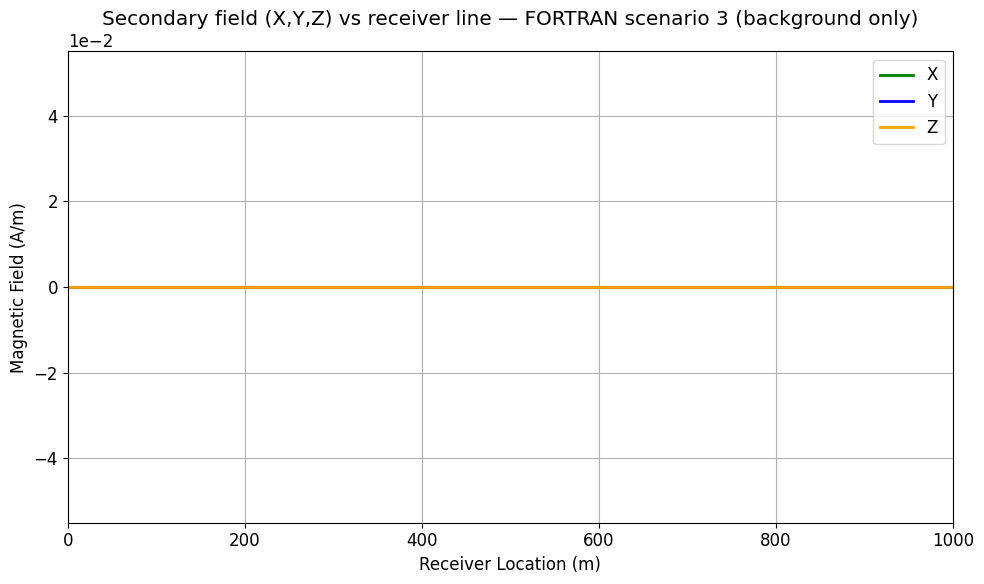

In [14]:
plot_total(fort['background'], 'FORTRAN scenario 3 (background only)')
plot_secondary(fort['background'], 'FORTRAN scenario 3 (background only)')

## Fortran vs Python comparison (optional)
If the Python-IE output files (`h-field-IE-*-100Hz.dat` — rerun the Python notebook with `>> Frequency (Hz)` set to `100.` and rename its outputs accordingly) are in this folder, overlay the two implementations and print the maximum relative difference over significant values. Expect agreement to the 5 printed digits everywhere the field is above the single-precision noise floor; tiny values deep in the exponential-decay tail (1e-30s and below) differ because the Fortran runs in single precision and the Python in double.

In [15]:
pairs = [('conductive', 'scenario 1'), ('zerocontrast', 'scenario 2'),
         ('background', 'scenario 3')]
for s, label in pairs:
    pyfile = f'h-field-IE-{s}-100Hz.dat'
    if not os.path.exists(pyfile):
        print(f'{pyfile} not found - skipping {label}')
        continue
    pyd = pd.read_csv(pyfile, sep=r'\s+', skiprows=1, names=COLS)
    F = fort[s][COLS[3:]].to_numpy()
    P = pyd[COLS[3:]].to_numpy()
    scale = np.maximum(np.abs(F), np.abs(P))
    sig = scale > 1e-9*np.abs(F).max()
    rel = np.zeros_like(F)
    rel[sig] = np.abs(F - P)[sig]/scale[sig]
    ident = 100*np.mean(F[sig] == P[sig])
    print(f'{label} ({s}): max rel diff (significant values) = '
          f'{rel[sig].max():.3e};  identical printed digits: {ident:.1f}%')

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(fort[s]['X'], fort[s]['Tot_Z_Re'], '-', color='0.6', lw=3.5,
            label='Fortran, Tot Z')
    ax.plot(pyd['X'], pyd['Tot_Z_Re'], 'r--', lw=1.2, label='Python IE, Tot Z')
    ax.plot(fort[s]['X'], fort[s]['Sec_Z_Re'], '-', color='0.6', lw=3.5)
    ax.plot(pyd['X'], pyd['Sec_Z_Re'], 'b--', lw=1.2, label='Python IE, Sec Z')
    ax.set_xlim(0, 1000)
    ax.set_yscale('symlog', linthresh=1e-30)
    ax.set_xlabel('Receiver Location (m)')
    ax.set_ylabel('H (A/m)')
    ax.set_title(f'Fortran vs Python — Total & Secondary Hz (Re), {label}')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

h-field-IE-conductive-100Hz.dat not found - skipping scenario 1
h-field-IE-zerocontrast-100Hz.dat not found - skipping scenario 2
h-field-IE-background-100Hz.dat not found - skipping scenario 3
